# 02 — Baseline Model
Linear Regression on World Happiness Data

In [1]:
import sys
sys.path.insert(0, '..')
import matplotlib.pyplot as plt
from src.data_processing import load_splits
from src.model import BaselineModel
from src.utils import plot_actual_vs_predicted
%matplotlib inline

## 1. Load Data

In [2]:
X_train, X_test, y_train, y_test = load_splits('../data/processed')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 1,692 | Test: 424


## 2. Train Baseline

In [3]:
model = BaselineModel()
model.train(X_train, y_train)
model.save('../models/baseline.pkl')

Training baseline (Linear Regression)...
Done.
Saved to ../models/baseline.pkl


## 3. Evaluate

In [4]:
results = model.evaluate(X_test, y_test, split_name='Baseline Test')


── Baseline Test Results ──
MAE:  0.7041
RMSE: 0.8982
R²:   0.3546


## 4. Actual vs Predicted

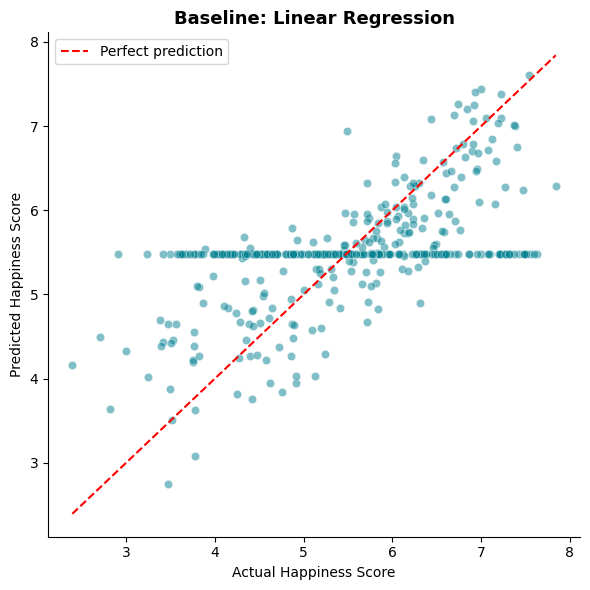

In [5]:
preds = model.predict(X_test)
fig = plot_actual_vs_predicted(y_test, preds, title='Baseline: Linear Regression')
plt.show()

## 5. Coefficients

In [6]:
import pandas as pd
from src.data_processing import FEATURES
coef = pd.Series(model.model.coef_, index=FEATURES).sort_values(ascending=False)
print('Feature Coefficients:')
print(coef.round(4))

Feature Coefficients:
explained_generosity                 1.8293
explained_corruption                 1.3441
explained_healthy_life_expectancy    1.3224
explained_social_support             1.0069
explained_log_gdp_per_capita         0.6251
explained_freedom                    0.5254
dtype: float64
